In [1]:
import sys
import time
import os
from os.path import join
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score

# Add paths to system
REPO = join("/orange/sai.zhang/khoa/repos/ukbb_gwas", "bin")
MODEL = join("/orange/sai.zhang/khoa/repos/ukbb_gwas", "model")
sys.path.insert(0, REPO)
sys.path.insert(0, MODEL)

# Import custom modules
from exomeloader import VariantLoader, EmbeddingLoader, ExomeLoader
from utils import check_ram, check_gpu
# from sgformer import SGFormer
from dataloader import ExomeDataset

In [2]:
multilabel_matrix_path = "/orange/sai.zhang/UKBB/finngen/label_matrix.npy"
sample_path = "/orange/sai.zhang/UKBB/finngen/sample_uid.txt"
variant_db = join("/orange/sai.zhang/khoa/data/UKBB/processed", "sqlite/ukbb_sample_indexed_merged2.db")
embedding_db = join("/orange/sai.zhang/khoa/data/UKBB/processed", "embeddings/protein_embeddings.h5")
refseq_path = "/orange/sai.zhang/khoa/data/RefSeqGene/GRCh38_latest_rna.gbff.tsv"
network_path = "/orange/sai.zhang/khoa/data/biokg.csv"
REF_DB = join("/orange/sai.zhang/khoa/data/UKBB/processed", "ref_exome_auto_mane.csv")
normalization_matrix = np.load(join("/orange/sai.zhang/khoa/data/UKBB/processed", "normalization_auto_mane.npz"))
count_path = "/orange/sai.zhang/khoa/repos/ukbb_gwas/notebooks/variant_counts_all.csv"

# Initialize loaders
embedding_loader = EmbeddingLoader(embedding_db, metric="mean")
variant_loader = VariantLoader(variant_db, "merged_variants")
exome_loader = ExomeLoader(variant_loader, embedding_loader, REF_DB)    

# Load and process data
eur_samples = VariantLoader(variant_db, "merged_variants").get_all_samples()
multilabel_matrix = np.load(multilabel_matrix_path)
sample_ids = pd.read_csv(sample_path, header=None).to_numpy().flatten()

Loading embeddings: 100%|██████████| 24/24 [00:48<00:00,  2.03s/it]


In [3]:
ref_db = exome_loader.reference_db #filter for chr19 and gene of choice
ref_db = ref_db[ref_db["chr"] == "chr19"]
ref_db = ref_db[ref_db["Gene"] == "ABHD8"]

In [4]:
ref_db.rename(columns={"transcript": "rna_id"}, inplace=True)
ref_db

,chr,rna_id,ID,Gene
15400,chr19,NM_024527,ref_27622,ABHD8


In [5]:
ref_embeddings = embedding_loader.get_ref_embeddings()

In [6]:
import ast

variants_df = pd.read_csv("/orange/sai.zhang/jsubroto/data/chr19_aa_variants.csv")

variant_map = pd.read_csv("/orange/sai.zhang/jsubroto/data/chr19_variants.csv.fixed")
variant_map.head()

,sample,rna_id,ID
0,2024215,NM_000400,chr19_816651
1,2024215,NM_000435,chr19_311355
2,2024215,NM_000479,chr19_626801
3,2024215,NM_000528,chr19_475269
4,2024215,NM_000635,chr19_227815


In [7]:
#map the variants to the ref_db using rna_id
merged_df = pd.merge(
    variants_df,                  
    ref_db,
    on=["rna_id"],
    how="inner"
)

In [8]:
def safe_parse(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            return []
    return val  #already a list or something else

merged_df['variants'] = merged_df['variants'].apply(safe_parse) #convert to python list

#filter for variants list of certain length
filtered_df = merged_df[merged_df['variants'].apply(lambda x: isinstance(x, list) and len(x) == 3)]

filtered_df.head(20)

,sample,rna_id,variants,chr,ID,Gene
10099,4623790,NM_024527,"[p.G254S, p.Y253S, p.G70R]",chr19,ref_27622,ABHD8
12029,3367364,NM_024527,"[p.L416R, p.G70R, p.V21M]",chr19,ref_27622,ABHD8
26692,1422236,NM_024527,"[p.E421A, p.E421X, p.G70R]",chr19,ref_27622,ABHD8
27989,4512264,NM_024527,"[p.E421A, p.E421X, p.G70R]",chr19,ref_27622,ABHD8
32604,2913294,NM_024527,"[p.G145R, p.S144N, p.G70R]",chr19,ref_27622,ABHD8
35622,4515406,NM_024527,"[p.G70R, p.D7N, p.D7H]",chr19,ref_27622,ABHD8
36083,5598736,NM_024527,"[p.S423X, p.S423A, p.G186S]",chr19,ref_27622,ABHD8
36538,5506183,NM_024527,"[p.G145R, p.S144N, p.G70R]",chr19,ref_27622,ABHD8
37541,2283826,NM_024527,"[p.G70R, p.V21M, p.V21L]",chr19,ref_27622,ABHD8
64610,4417281,NM_024527,"[p.E421A, p.E421X, p.G70R]",chr19,ref_27622,ABHD8


In [9]:
#check the variants and samples to see whether there is an early stop.
reference_df = pd.read_csv("/orange/sai.zhang/jsubroto/data/GRCh38_latest_rna.gbff.tsv", sep = "\t")

In [10]:
variants_map_fixed = pd.read_csv("/orange/sai.zhang/jsubroto/data/chr19_variants_id_map.csv.fixed")
#filter for chr19_674717
filter_variants_map_fixed = variants_map_fixed[variants_map_fixed["ID"] == "chr19_674717"]
filter_variants_map_fixed

,CDS,Protein,ID
674717,ATGAAGGTTCTGTGGGCTGCGTTGCTGGTCACATTCCTGGCAGGAT...,MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWEL...,chr19_674717


In [11]:
reference_df

,Sequence,Accession,Organism,Gene,Locus_Tag,Protein_ID,Start,End,Strand,Protein_Sequence,CDS
0,GGGACCAGATGGATTGTAGGGAGTAGGGTACAATACAGTCTGTTCT...,NM_000014.6,Homo sapiens,A2M,Unknown,NP_000005.3,70,4495,1,MGKNKLLHPSLVLLLLVLLPTDASVSGKPQYMVLVPSLLHTETTEK...,ATGGGGAAGAACAAACTCCTTCATCCAAGTCTGGTTCTTCTCCTCT...
1,ACTTTATTACAGACCTTGGAAGCAAGAGGATTGCATTCAGCCTAGT...,NM_000015.3,Homo sapiens,NAT2,Unknown,NP_000006.2,70,943,1,MDIEAYFERIGYKNSRNKLDLETLTDILEHQIRAVPFENLNMHCGQ...,ATGGACATTGAAGCATATTTTGAAAGAATTGGCTATAAGAACTCTA...
2,AGAGGAGTCCCGCGTTCGGGGAGTATGTCAAGGCCGTGACCCGTGT...,NM_000016.6,Homo sapiens,ACADM,Unknown,NP_000007.1,79,1345,1,MAAGFGRCCRVLRSISRFHWRSQHTKANRQREPGLGFSFEFTEQQK...,ATGGCAGCGGGGTTCGGGCGATGCTGCAGGGTCCTGAGAAGTATTT...
3,ACTCCGGAACAGCGCGCTCGCAGCGGGAGGTCGCGAAGCCTGGGAC...,NM_000017.4,Homo sapiens,ACADS,Unknown,NP_000008.1,60,1299,1,MAAALLARASGPARRALCPRAWRQLHTIYQSVELPETHQMLLQTCR...,ATGGCCGCCGCGCTGCTCGCCCGGGCCTCGGGCCCTGCCCGCAGAG...
4,AGAGCTGGGTCAGAGCTCGAGCCAGCGGCGCCCGGAGAGATTCGGA...,NM_000018.4,Homo sapiens,ACADVL,Unknown,NP_000009.1,47,2015,1,MQAARMAASLGRQLLRLGGGSSRLTALLGQPRPGPARRPYAGGAAQ...,ATGCAGGCGGCTCGGATGGCCGCGAGCTTGGGGCGGCAGCTGCTGA...
...,...,...,...,...,...,...,...,...,...,...,...
136264,CGCGGCCGCCTGTCTGCACAGACAGCACCATGTCGCTCATGGTCGT...,XM_060077550.1,Homo sapiens,KIR2DL2,Unknown,XP_059933533.1,29,1076,1,MSLMVVSMACVGFFLLQGAWPHEGVHRKPSLLAHPGRLVKSEETVI...,ATGTCGCTCATGGTCGTCAGCATGGCGTGTGTTGGGTTCTTCTTGC...
136265,CGCGGCCGCCTGTCTGCACAGACAGCACCATGTCGCTCATGGTCGT...,XM_060077551.1,Homo sapiens,KIR2DL2,Unknown,XP_059933534.1,29,1076,1,MSLMVVSMACVGFFLLQGAWPHEGVHRKPSLLAHPGRLVKSEETVI...,ATGTCGCTCATGGTCGTCAGCATGGCGTGTGTTGGGTTCTTCTTGC...
136266,CGCGGCCGCCTGTCTGCACAGACAGCACCATGTCGCTCATGGTCGT...,XM_060077552.1,Homo sapiens,KIR2DL2,Unknown,XP_059933535.1,29,1076,1,MSLMVVSMACVGFFLLQGAWPHEGVHRKPSLLAHPGRLVKSEETVI...,ATGTCGCTCATGGTCGTCAGCATGGCGTGTGTTGGGTTCTTCTTGC...
136267,GCGCCTCCCAACCCTGAAGCCCGCCCTGGAAGCGAAATCCTTGCCT...,XM_067756347.1,Homo sapiens,LOC124906892,Unknown,XP_067612448.1,160,871,1,MEARSEEKGKMGKILFKAPGHSCLSARPPRPLKPDAVSSSGALDED...,ATGGAGGCAAGGTCAGAGGAAAAGGGAAAAATGGGAAAGATTTTAT...


In [12]:
print(reference_df.columns.tolist())

['Sequence', 'Accession', 'Organism', 'Gene', 'Locus_Tag', 'Protein_ID', 'Start', 'End', 'Strand', 'Protein_Sequence', 'CDS']


In [13]:
reference_df['Accession'] = reference_df['Accession'].str.split('.').str[0]
reference_df = reference_df.rename(columns={"Accession": "rna_id"})
matches = reference_df[reference_df['rna_id'] == "NM_000041"]
matches.head()

if matches["CDS"].iloc[0] == filter_variants_map_fixed["CDS"].iloc[0]:
    print("true")

true


In [14]:
merge_match = pd.merge(
    matches,
    filtered_df,
    on=['rna_id', 'Gene'],
    how="inner"
)

merge_match["CDS_length"] = merge_match["CDS"].str.len()
merge_match["CDS_aa_estimate"] = merge_match["CDS_length"] // 3
merge_match["Protein_length"] = merge_match["Protein_Sequence"].str.len()

merge_match

,Sequence,rna_id,Organism,Gene,Locus_Tag,Protein_ID,Start,End,Strand,Protein_Sequence,CDS,sample,variants,chr,ID,CDS_length,CDS_aa_estimate,Protein_length


In [15]:
merged_df2 = pd.merge(
    filtered_df,                  
    variant_map,
    on=["rna_id","sample"],
    how="inner"
)

merged_df2

,sample,rna_id,variants,chr,ID_x,Gene,ID_y
0,4623790,NM_024527,"[p.G254S, p.Y253S, p.G70R]",chr19,ref_27622,ABHD8,chr19_84767
1,3367364,NM_024527,"[p.L416R, p.G70R, p.V21M]",chr19,ref_27622,ABHD8,chr19_378453
2,1422236,NM_024527,"[p.E421A, p.E421X, p.G70R]",chr19,ref_27622,ABHD8,chr19_513238
3,4512264,NM_024527,"[p.E421A, p.E421X, p.G70R]",chr19,ref_27622,ABHD8,chr19_513238
4,2913294,NM_024527,"[p.G145R, p.S144N, p.G70R]",chr19,ref_27622,ABHD8,chr19_84767
5,4515406,NM_024527,"[p.G70R, p.D7N, p.D7H]",chr19,ref_27622,ABHD8,chr19_84767
6,5598736,NM_024527,"[p.S423X, p.S423A, p.G186S]",chr19,ref_27622,ABHD8,chr19_390825
7,5506183,NM_024527,"[p.G145R, p.S144N, p.G70R]",chr19,ref_27622,ABHD8,chr19_84767
8,2283826,NM_024527,"[p.G70R, p.V21M, p.V21L]",chr19,ref_27622,ABHD8,chr19_84767
9,4417281,NM_024527,"[p.E421A, p.E421X, p.G70R]",chr19,ref_27622,ABHD8,chr19_513238


In [16]:
merged_df2.head(20)

target = ["p.Y253S", "p.G70R"]

# Check if all target values are in each row's list
merged_df2['has_all'] = merged_df2['variants'].apply(lambda x: all(item in x for item in target))

# Filter the matching rows
df_matched = merged_df2[merged_df2['has_all']]

df_matched

,sample,rna_id,variants,chr,ID_x,Gene,ID_y,has_all
0,4623790,NM_024527,"[p.G254S, p.Y253S, p.G70R]",chr19,ref_27622,ABHD8,chr19_84767,True


In [17]:
variant_map[(variant_map["rna_id"] == "NM_000041") & (variant_map["sample"] == 2674171)]

,sample,rna_id,ID
199552269,2674171,NM_000041,chr19_674717


In [18]:
#unique ID_Y
merged_df2['ID_y'] = merged_df2['ID_y'].str.split('_').str[1].astype(int)
merged_df2["ID_y"].unique()


array([ 84767, 378453, 513238, 390825, 574911])

In [19]:
target_variants = ["p.E188G"]
matching_rows = merged_df2[
    merged_df2['variants'].apply(lambda x: all(v in x for v in target_variants) and len(x) == 2)
]

matching_rows


,sample,rna_id,variants,chr,ID_x,Gene,ID_y,has_all


In [20]:
#embed difference in variant list length 1
ref = ref_embeddings[27693]

variants_1 = [393950, 274876, 674717, 314426,  84537, 393069, 716520,  20952,
       292193,   7133,  97508, 348327, 460503, 519132, 447810, 589826,
         2129, 531352, 259406, 792507,  27132, 376911, 682845, 551902,
       616497, 130171, 339558, 740869, 402149, 360443, 729588, 213656,
       328496,  49247, 338024, 478603, 385377, 813396, 495882, 324177,
       607517, 344242, 466863, 730651, 691965, 176135, 370114, 262551,
       297768, 741892, 368144, 680291, 112670,  15617, 503086, 520278,
       479670, 756436, 393426, 175698, 704554, 255219, 184289, 684688,
       196930, 276437, 591146,  28487,  51294, 115427, 409974,  37220,
       183064, 643571, 126532, 444872, 419376, 165097,  22585, 534531,
       748500, 665701, 274324, 520633, 699094, 312090, 182088, 409624,
       682857, 674844, 686170, 592828, 169122, 673198, 808780, 503921,
       331468, 136926, 744926, 221446,  52798, 576993, 338253, 517346,
        30637, 468018, 269937, 338557,  66342, 570137, 521463, 601032,
       644528,  40290, 117568, 129066, 364174, 445131, 228233, 460306,
       336819, 403552, 363256, 651491, 546110, 766143, 690344, 281899,
       215639, 672025, 505212, 573555, 358064, 468159, 557081, 155689,
       559378, 317590, 723000, 335999, 374970, 640382, 549568, 502372,
        58372, 198857, 614144, 729830,  67836, 424761, 665810, 135708,
         3510, 360234, 103914, 519329, 389464]

total = 0

for variant in variants_1:
    variant_embed = embedding_loader.get_embeddings("chr19", [variant])
    diff = ref - variant_embed
    distance = np.linalg.norm(diff) 
    total += distance

mean_1 = total / len(variants_1)
print("Mean distance:", mean_1)


Mean distance: 0.0212807866809949


In [21]:
#variants list length 2
variants_2 = [749804,   8316, 323739, 393950, 129831, 147555, 274876, 371722,
       403716, 208608, 615839,  29818, 674717, 308765, 367981, 659771,
       556727, 166041, 564535, 519132, 728183, 306808,  61428, 632080,
       262361, 247053, 177084, 413987, 610884, 215610, 214123, 164581,
       302826, 546489, 729918, 566491, 444872, 769525, 673213, 607645,
       660964, 484688,   3946, 447810, 216777, 595364, 735413, 243579,
       642576,  83745, 196930, 419930, 275666,  86142, 217052, 391708,
       261874, 565199, 360064, 761375,  19848, 260472, 630388, 701159,
       784052, 679447, 761169, 263047,  23118, 225003, 809773, 524425,
       764916, 570702, 333419, 368713, 109980, 588431, 121580, 339488,
       259834,  29670, 366291, 265038, 436983, 697862, 508037, 636976,
       237286, 717426, 595726, 762531, 497706, 545135, 478124, 671573,
       672980,  72626,  63630, 422523, 688576, 261351, 654769, 139536,
       339077, 397386, 172599, 706745, 536824, 262596, 750710,  84537,
       687891,  46748, 424310, 460503, 622890, 607510, 453483, 561655,
       497190, 672921,  89355, 674778, 248801, 105000,  31320, 150451,
       659088, 723342,  15617, 641447, 373454, 759063, 246476, 564051,
       596140,   8761, 188172, 708943, 608139,  23765, 812893, 509101,
       755333, 121201, 775680, 813814,  63344, 269982, 548316, 672414,
       347181, 268065, 108993, 393639, 294848, 294548, 640237, 591465,
       575246, 430305, 338253, 722318, 407086, 183855, 398217, 812373,
       226627, 269384, 399335, 368887, 816679, 785879, 176838, 415553,
       385815, 441593, 369882, 348327, 351762, 305635, 421603, 229790,
       722054, 360632, 528079,   2129, 718064,  19823, 551746,   7133,
       489007, 785255, 330170, 525603, 394482, 226163, 784613, 403580,
       355406, 551208, 517697, 533114, 109836, 254535, 697154, 453134,
       654100, 727793, 199381, 716156, 387603,  21348,  54114, 127058]

total = 0

for variant in variants_2:
    variant_embed = embedding_loader.get_embeddings("chr19", [variant])
    diff = ref - variant_embed
    distance = np.linalg.norm(diff) 
    total += distance

mean_2 = total / len(variants_2)
print("Mean distance:", mean_2)


Mean distance: 0.05199507484643685


In [22]:
#variants list length 3
variants_3 = [180428, 749804, 319899, 448000, 497987, 147555, 323739, 393950,
       538211, 674717, 542891, 274876,  65894,  84537, 343443, 160799,
       275666, 216777, 753408, 371722, 501697, 541370, 666526, 365412,
       342434, 521781, 499086, 323901, 324317, 201916, 212142, 743840,
       294302, 306808, 534592, 129831, 411416, 226163,  41007,   8316,
       710737, 216679,  27778, 260710, 337424, 562638, 593727]

total = 0

for variant in variants_3:
    variant_embed = embedding_loader.get_embeddings("chr19", [variant])
    diff = ref - variant_embed
    distance = np.linalg.norm(diff) 
    total += distance

mean_3 = total / len(variants_3)
print("Mean distance:", mean_3)

Mean distance: 0.03646935078691929


In [23]:
#variants list length 4
variants_4 = [393950, 674717, 749804, 343443,
       180428, 319899]

total = 0

for variant in variants_4:
    variant_embed = embedding_loader.get_embeddings("chr19", [variant])
    diff = ref - variant_embed
    distance = np.linalg.norm(diff) 
    total += distance

mean_4 = total / len(variants_4)
print("Mean distance:", mean_4)



Mean distance: 0.021718779268364113


In [24]:
diff

array([[-8.148579e-04, -8.614734e-06,  6.653238e-04, ...,  4.257782e-04,
        -6.808485e-04,  7.571917e-04]], dtype=float32)

In [25]:
#variants list length 5
variants_5 = [674717]
print(embedding_loader.get_embeddings("chr19", [674717]))

total = 0

for variant in variants_5:
    variant_embed = embedding_loader.get_embeddings("chr19", [variant])
    diff = ref - variant_embed
    distance = np.linalg.norm(diff) 
    total += distance

mean_5 = total / len(variants_5)
print("Mean distance:", mean_5)

[[ 0.00905429  0.01155925 -0.01971442 ...  0.00201716 -0.00204529
  -0.00134252]]
Mean distance: 0.0


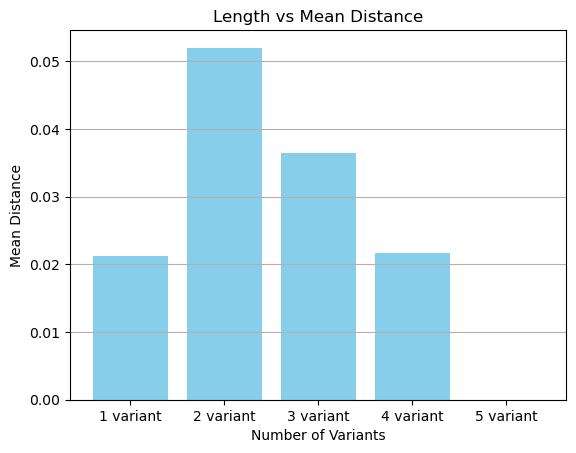

In [26]:
import matplotlib.pyplot as plt

x = ["1 variant", "2 variant", "3 variant", "4 variant", "5 variant"]
y = [0.0212807866809949, 0.05199507484643685, 0.03646935078691929, 0.021718779268364113, 0.0]

plt.bar(x, y, color='skyblue')
plt.xlabel("Number of Variants")
plt.ylabel("Mean Distance")
plt.title("Length vs Mean Distance")
plt.grid(axis='y') 
plt.show()

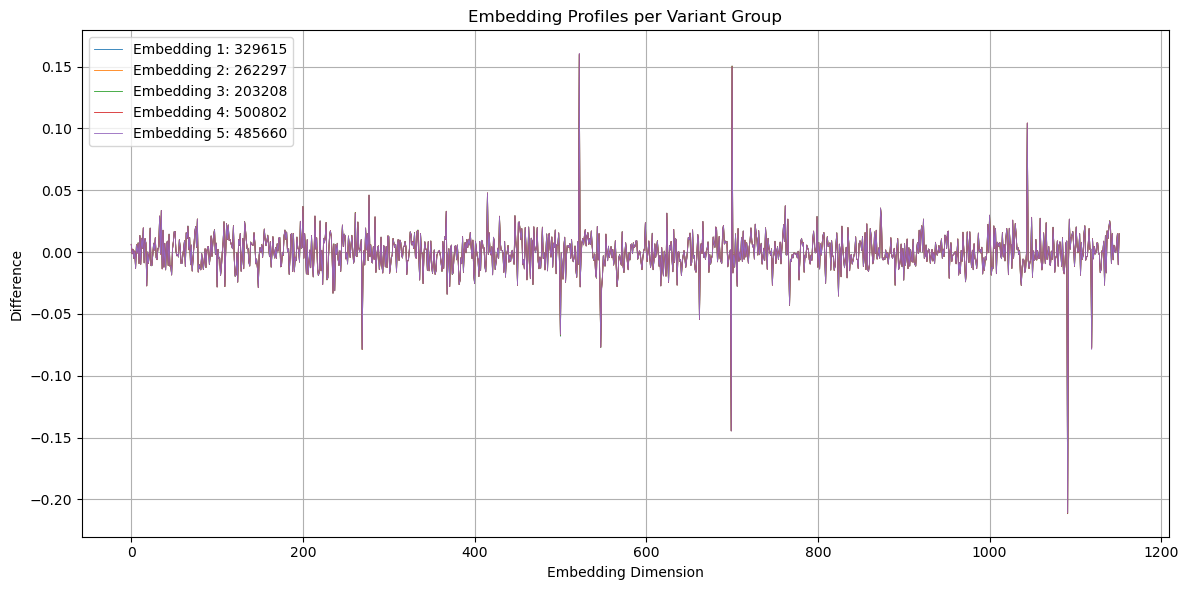

In [27]:
"""ABCA7"""
import matplotlib.pyplot as plt
a = [
    329615,#[p.M347K]
    262297,#[p.M347K, p.A2045S]
    203208,#[p.M347K, p.G1527A, p.A2045S]
    500802, #[p.M347K, p.R1349Q, p.G1527A, p.A2045S]
    485660 #[p.E188G, p.M347K, p.R1349Q, p.G1527A, p.A2045S] 
]

plt.figure(figsize=(12, 6))

for i, variant_id in enumerate(a, 1):
    embed = embedding_loader.get_embeddings("chr19", [variant_id]).flatten()
    difference = ref - embed
    plt.plot(range(len(embed)), difference, label=f"Embedding {i}: {variant_id}", linewidth=0.6)

plt.xlabel("Embedding Dimension")
plt.ylabel("Difference")
plt.title("Embedding Profiles per Variant Group")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


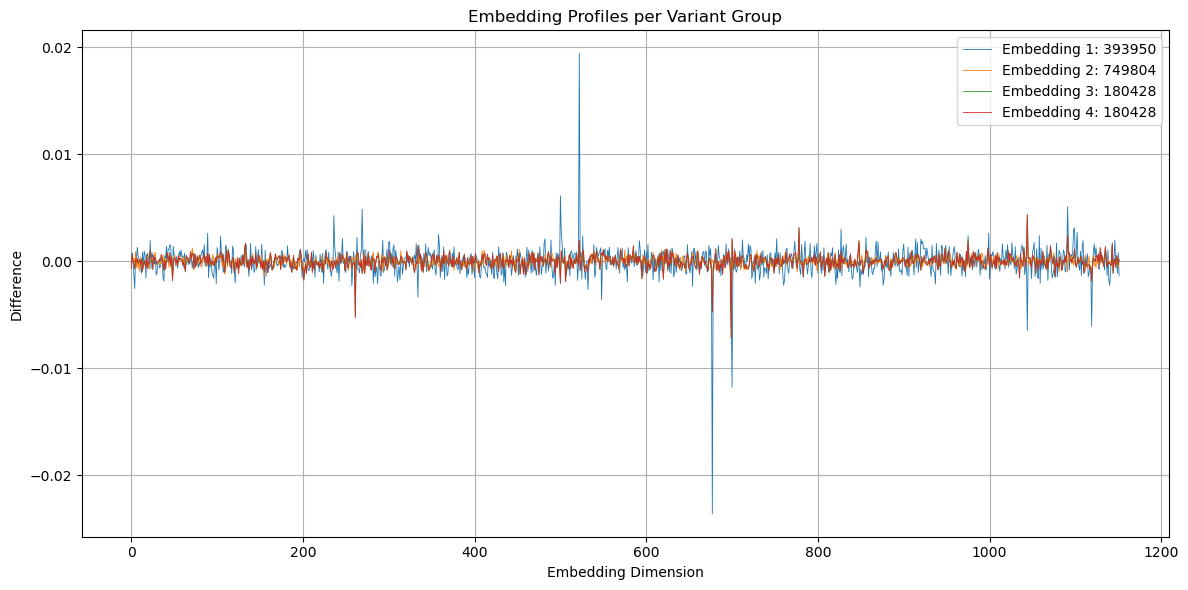

In [28]:
"""APOE"""
#graph embedding with 1 variant
#graph embedding with 2 variants but keep the original variant

v = [393950, #C130R 
    749804, #p.C130R, p.R176C
    180428,#[p.C130R, p.R176C, p.R269G]
    180428, #[p.F51I, p.C130R, p.R176C, p.R269G]
]

plt.figure(figsize=(12, 6))

for i, variant_id in enumerate(v, 1):
    embed = embedding_loader.get_embeddings("chr19", [variant_id]).flatten()
    difference = ref - embed
    plt.plot(range(len(embed)), difference, label=f"Embedding {i}: {variant_id}", linewidth=0.6)

plt.xlabel("Embedding Dimension")
plt.ylabel("Difference")
plt.title("Embedding Profiles per Variant Group")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

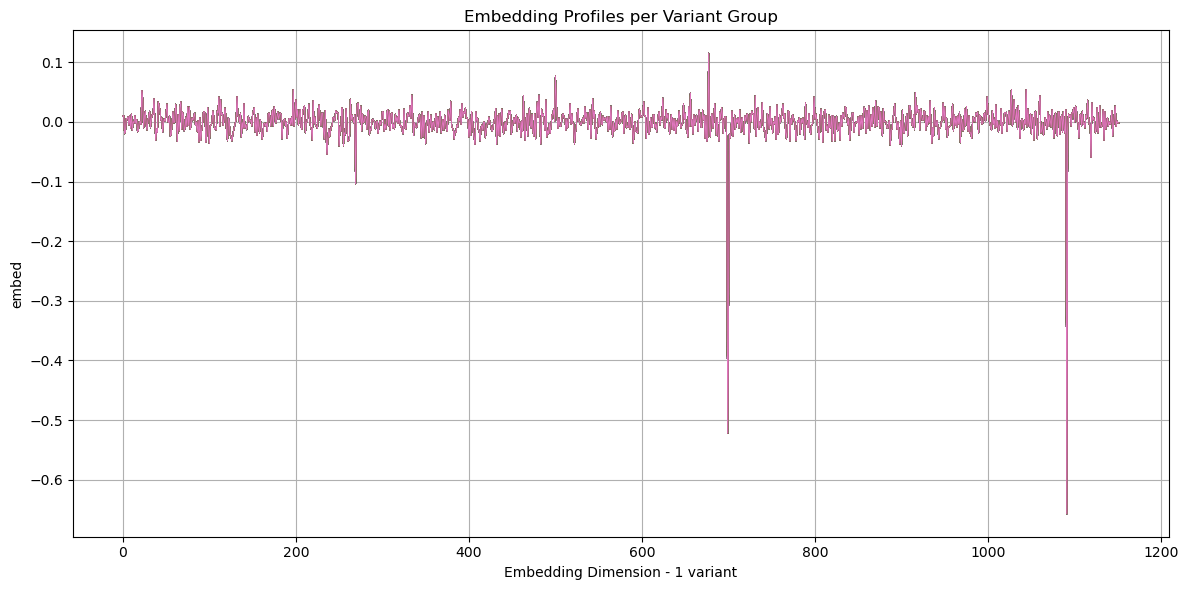

In [29]:
#graph comparing embeds of 1 variant
plt.figure(figsize=(12, 6))

for i, variants_id in enumerate(variants_1,1):
    embed = embedding_loader.get_embeddings("chr19", [variant_id]).flatten()
    plt.plot(range(len(embed)), embed, label=f"Embedding {i}: {variant_id}", linewidth=0.6)

plt.xlabel("Embedding Dimension - 1 variant")
plt.ylabel("embed")
plt.title("Embedding Profiles per Variant Group")
plt.grid(True)
plt.tight_layout()
plt.show()

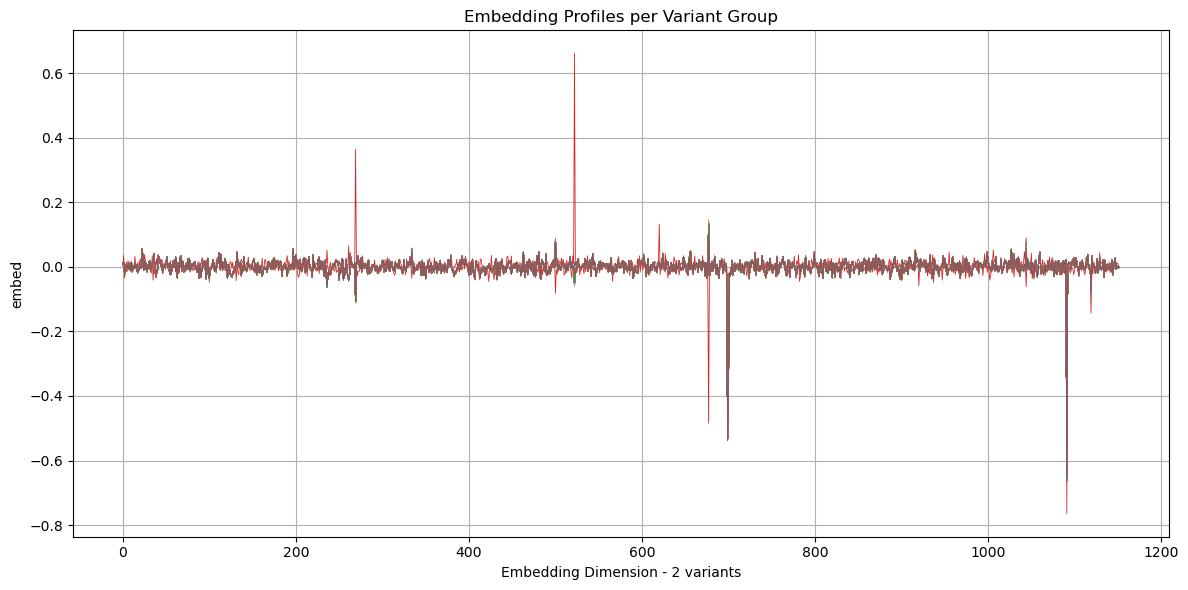

In [30]:
#graph comparing embeds of 2 variants
plt.figure(figsize=(12, 6))

for i, variant_id in enumerate(variants_2,1):
    embed = embedding_loader.get_embeddings("chr19", [variant_id]).flatten()
    plt.plot(range(len(embed)), embed, label=f"Embedding {i}: {variant_id}", linewidth=0.6)

plt.xlabel("Embedding Dimension - 2 variants")
plt.ylabel("embed")
plt.title("Embedding Profiles per Variant Group")
plt.grid(True)
plt.tight_layout()
plt.show()

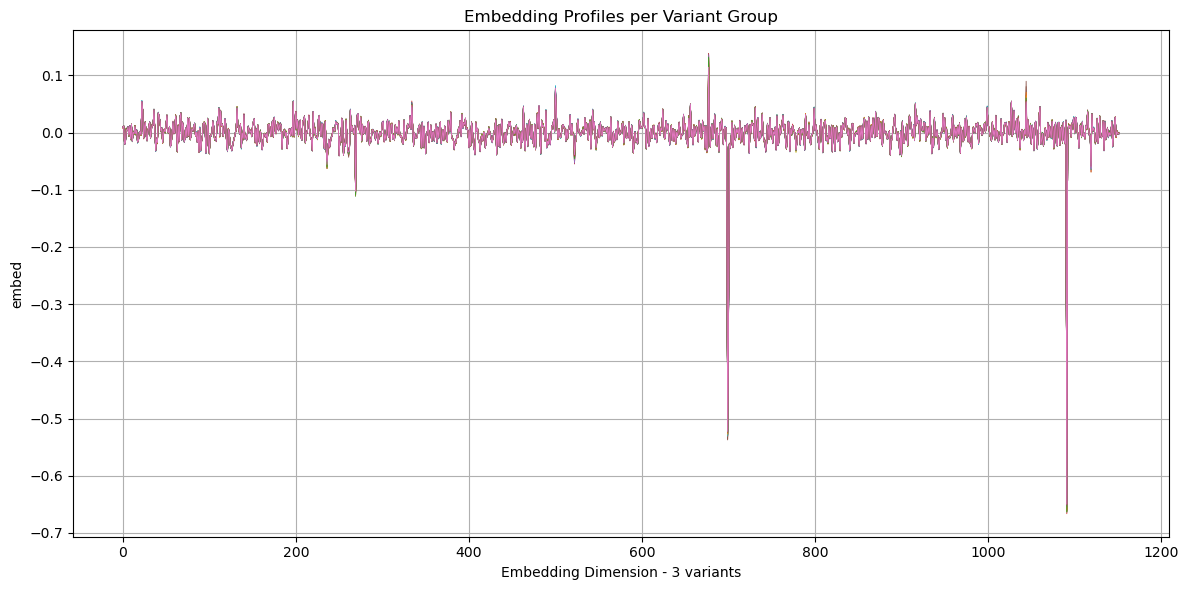

In [31]:
#graph comparing embeds of 3 variants
plt.figure(figsize=(12, 6))

for i, variant_id in enumerate(variants_3,1):
    embed = embedding_loader.get_embeddings("chr19", [variant_id]).flatten()
    plt.plot(range(len(embed)), embed, label=f"Embedding {i}: {variant_id}", linewidth=0.6)

plt.xlabel("Embedding Dimension - 3 variants")
plt.ylabel("embed")
plt.title("Embedding Profiles per Variant Group")
plt.grid(True)
plt.tight_layout()
plt.show()

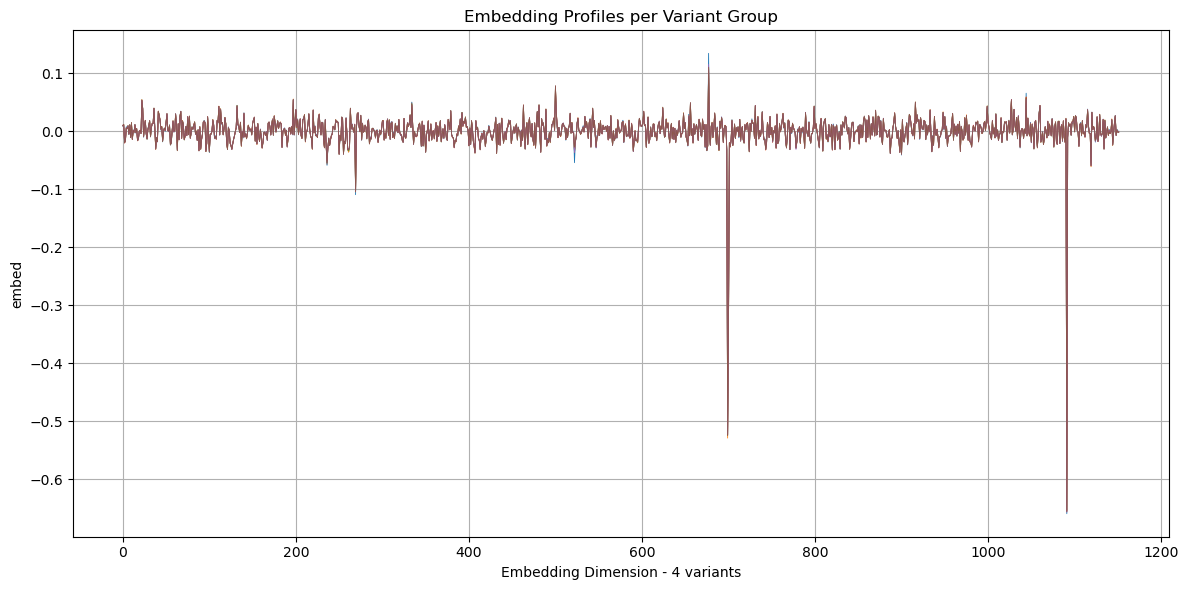

In [32]:
#graph comparing embeds of 4 variants
plt.figure(figsize=(12, 6))

for i, variant_id in enumerate(variants_4,1):
    embed = embedding_loader.get_embeddings("chr19", [variant_id]).flatten()
    plt.plot(range(len(embed)), embed, label=f"Embedding {i}: {variant_id}", linewidth=0.6)

plt.xlabel("Embedding Dimension - 4 variants")
plt.ylabel("embed")
plt.title("Embedding Profiles per Variant Group")
plt.grid(True)
plt.tight_layout()
plt.show()